<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/GW190814_draw_90pc_probability_contour_05032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
                       "astropy", "astropy-healpix"])

0

In [6]:
import numpy as np, astropy
print("numpy:", np.__version__)
print("astropy:", astropy.__version__)

numpy: 1.26.4
astropy: 7.2.0


In [7]:
import numpy as np
import os, inspect
print("numpy version:", np.__version__)
print("numpy file:", inspect.getfile(np))
print("has in1d:", hasattr(np, "in1d"))
print("cwd:", os.getcwd())

numpy version: 1.26.4
numpy file: /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
has in1d: True
cwd: /content


Skymap exists: True
Columns: ['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']
Detected raster sky map: NSIDE=1024, ORDERING=NESTED
Total prob: 1.0
Pixels in 90% region: 5642 mass: 0.9000003339167143


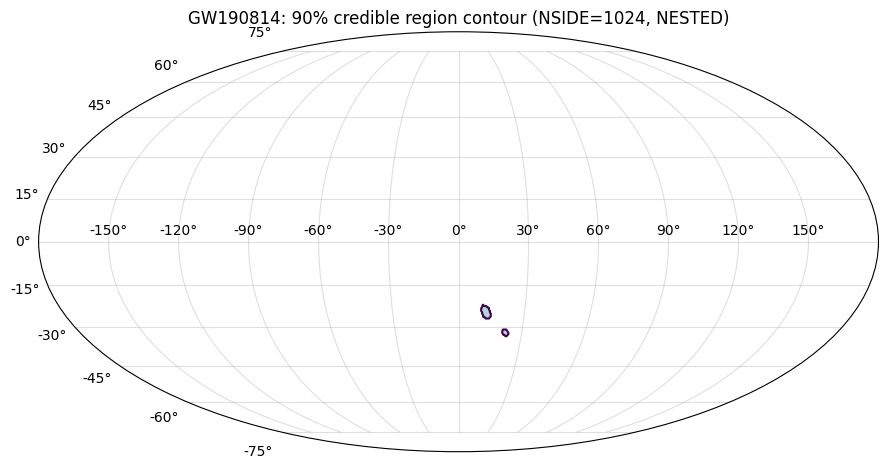

In [9]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# If the file is multi-order (UNIQ), we rasterize to this NSIDE:
TARGET_NSIDE_FOR_UNIQ = 256

# Plot grid resolution (higher = smoother contour, slower)
NGRID_LON = 720
NGRID_LAT = 360

FILL_REGION = True  # True = filled region + contour; False = contour only

# ---------- Imports (NO pip installs here) ----------
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix, uniq_to_level_ipix


# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

print("Skymap exists:", os.path.exists(fname))


# ---------- Read FITS header + table ----------
hdr = fits.getheader(fname, 1)  # extension 1 is usually the sky map table
t = Table.read(fname, hdu=1)
print("Columns:", t.colnames)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    print("Warning: Unknown ORDERING =", ordering, "-> assuming NESTED")
    ordering = "NESTED"

# astropy-healpix expects 'nested' or 'ring'
order_for_healpix = "nested" if ordering == "NESTED" else "ring"


# ---------- Case A: Raster HEALPix map (your file) ----------
# It has PROB and no UNIQ. PROB is probability *mass per pixel*.
if "UNIQ" not in t.colnames:
    if "PROB" not in t.colnames:
        raise KeyError("No UNIQ column and no PROB column found. Can't interpret this sky map.")

    nside = hdr.get("NSIDE", None)
    if nside is None:
        # Some files omit NSIDE keyword; infer from length if it's a full-sky HEALPix raster.
        npix = len(t["PROB"])
        # npix = 12 * nside^2  =>  nside = sqrt(npix/12)
        nside_guess = int(round(np.sqrt(npix / 12.0)))
        if 12 * nside_guess * nside_guess != npix:
            raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
        nside = nside_guess

    p = np.asarray(t["PROB"], dtype=float)
    # normalize (should already sum ~1, but be safe)
    tot = p.sum()
    if not np.isfinite(tot) or tot <= 0:
        raise RuntimeError("PROB column sums to non-finite or zero.")
    p = p / tot

    hp = HEALPix(nside=nside, order=order_for_healpix, frame="icrs")

    print(f"Detected raster sky map: NSIDE={nside}, ORDERING={ordering}")
    print("Total prob:", p.sum())

# ---------- Case B: Multi-order UNIQ map (fallback) ----------
else:
    uniq = np.asarray(t["UNIQ"])

    # Probability density per steradian column name variants
    probdens_col = None
    for c in ("PROBDENSITY", "PROB_DENSITY", "PROB_DENS"):
        if c in t.colnames:
            probdens_col = c
            break
    if probdens_col is None:
        raise KeyError("Found UNIQ but no probability-density column (PROBDENSITY / PROB_DENSITY / PROB_DENS).")

    probdens = np.asarray(t[probdens_col], dtype=float)  # 1/sr

    # Rasterize to fixed NSIDE in nested ordering (UNIQ is defined for nested)
    nside = TARGET_NSIDE_FOR_UNIQ
    target_level = int(np.log2(nside))
    if 2**target_level != nside:
        raise ValueError("TARGET_NSIDE_FOR_UNIQ must be a power of 2.")

    npix = 12 * nside * nside
    p = np.zeros(npix, dtype=float)

    level, ipix = uniq_to_level_ipix(uniq)
    level = np.asarray(level, dtype=int)
    ipix = np.asarray(ipix, dtype=np.int64)

    for L, I, pd in zip(level, ipix, probdens):
        nside_cell = 2**L
        area_cell = (4.0 * np.pi) / (12.0 * nside_cell * nside_cell)  # sr
        mass = pd * area_cell

        if L == target_level:
            if 0 <= I < npix:
                p[I] += mass
        elif L < target_level:
            d = target_level - L
            nchild = 4**d
            start = I * nchild
            end = start + nchild
            if start < npix:
                p[start:min(end, npix)] += mass / nchild
        else:
            d = L - target_level
            parent = I // (4**d)
            if 0 <= parent < npix:
                p[parent] += mass

    p /= p.sum()
    hp = HEALPix(nside=nside, order="nested", frame="icrs")
    print(f"Detected multi-order UNIQ sky map; rasterized to NSIDE={nside} (NESTED).")
    print("Total prob:", p.sum())


# ---------- 90% credible mask ----------
idx = np.argsort(p)[::-1]
cum = np.cumsum(p[idx])
k = np.searchsorted(cum, CREDIBLE, side="left")
k = min(k, len(idx) - 1)

mask = np.zeros_like(p, dtype=bool)
mask[idx[:k+1]] = True

print(f"Pixels in {int(CREDIBLE*100)}% region:", mask.sum(), "mass:", p[mask].sum())


# ---------- Contour plot (Mollweide) ----------
lon = np.linspace(-180, 180, NGRID_LON, endpoint=False) * u.deg
lat = np.linspace(-90, 90, NGRID_LAT) * u.deg
LON, LAT = np.meshgrid(lon, lat)

grid_pix = hp.lonlat_to_healpix(LON, LAT)
Z = mask[grid_pix].astype(float)

x = np.deg2rad(LON.to_value(u.deg))
y = np.deg2rad(LAT.to_value(u.deg))

fig = plt.figure(figsize=(9, 5.5))
ax = fig.add_subplot(111, projection="mollweide")

if FILL_REGION:
    ax.contourf(x, y, Z, levels=[0.5, 1.5], alpha=0.35)

ax.contour(x, y, Z, levels=[0.5], linewidths=1.5)

ax.grid(True, alpha=0.4)
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% credible region contour (NSIDE={hp.nside}, {ordering})")
plt.tight_layout()
plt.show()

Skymap exists: True
Columns: ['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']
Detected raster sky map: NSIDE=1024, ORDERING=NESTED
Total prob: 1.0
Pixels in 90% region: 5642 mass: 0.9000003339167143


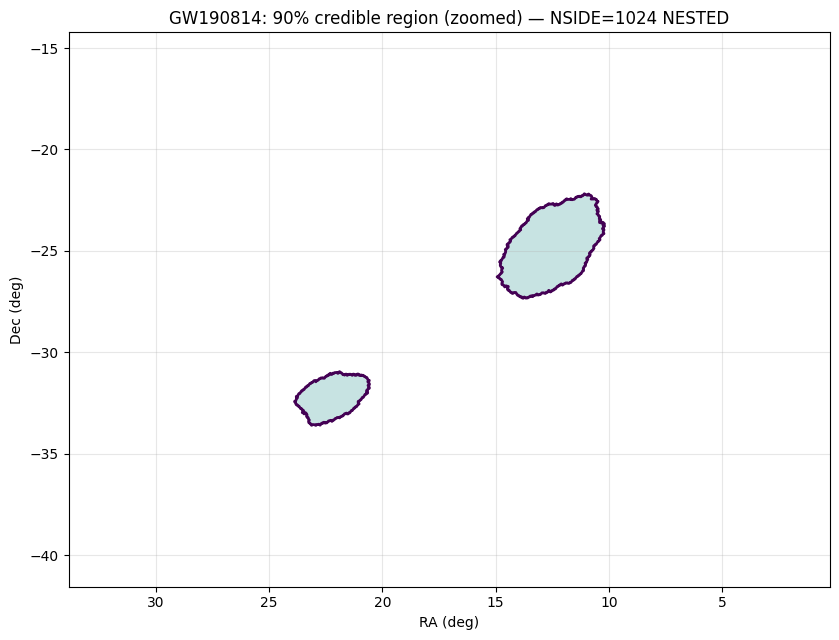

In [12]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Plot grid resolution (higher = smoother contour, slower)
NGRID_RA = 900
NGRID_DEC = 450

FILL_REGION = True  # True = filled region + contour; False = contour only

# ---------- Imports (NO pip installs here) ----------
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix


# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

print("Skymap exists:", os.path.exists(fname))


# ---------- Read FITS header + table ----------
hdr = fits.getheader(fname, 1)          # extension 1 is usually the sky map table
t = Table.read(fname, hdu=1)
print("Columns:", t.colnames)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
order_for_healpix = "nested" if ordering == "NESTED" else "ring"

if "PROB" not in t.colnames:
    raise KeyError("This file doesn't have a PROB column; it's not the raster format expected here.")

nside = hdr.get("NSIDE", None)
if nside is None:
    # Infer NSIDE from number of pixels if header is missing it
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p /= p.sum()  # normalize defensively

hp = HEALPix(nside=nside, order=order_for_healpix, frame="icrs")

print(f"Detected raster sky map: NSIDE={nside}, ORDERING={ordering}")
print("Total prob:", p.sum())


# ---------- 90% credible mask ----------
idx = np.argsort(p)[::-1]
cum = np.cumsum(p[idx])
k = np.searchsorted(cum, CREDIBLE, side="left")
k = min(k, len(idx) - 1)

mask = np.zeros_like(p, dtype=bool)
mask[idx[:k+1]] = True

print(f"Pixels in {int(CREDIBLE*100)}% region:", mask.sum(), "mass:", p[mask].sum())


# ---------- Zoomed RA/Dec plot ----------
mask_pix = np.where(mask)[0]
lon_c, lat_c = hp.healpix_to_lonlat(mask_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg=10.0):
    """Smallest RA arc covering points (wrap-safe), returned as ra_min, ra_max in 0..360."""
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    ra_min = (start - pad_deg) % 360.0
    ra_max = (end + pad_deg) % 360.0
    return ra_min, ra_max

def ra_linspace_wrap(ra_min, ra_max, n):
    """Linspace over an RA window that may cross 360."""
    ra_min = ra_min % 360.0
    ra_max = ra_max % 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    else:
        a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
        b = np.linspace(0.0, ra_max, n - len(a))
        return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, pad_deg=10.0)
dec_min = dec_c.min() - 8.0
dec_max = dec_c.max() + 8.0

ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp.lonlat_to_healpix(RA, DEC)

# --- credible level field instead of binary mask ---
order = np.argsort(p)[::-1]
cumprob = np.cumsum(p[order])
credible = np.empty_like(p)
credible[order] = cumprob

Z = credible[grid_pix]

plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0,0.9], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.9], linewidths=2)

# Invert RA axis (astronomy convention)
# Handle wrap: if window crosses 360, shift RA>180 down by 360 for a continuous axis.
ra_plot = RA.to_value(u.deg)
if ra_min > ra_max:  # wrap case
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0,0.9], alpha=0.25)
    ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.9], linewidths=2)
    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)  # inverted
else:
    ax.set_xlim(ra_max, ra_min)      # inverted

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% credible region (zoomed) — NSIDE={nside} {ordering}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Skymap exists: True
Columns: ['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']
Detected raster sky map: NSIDE=1024, ORDERING=NESTED
Total prob: 1.0
Pixels in 90% region: 5641 mass: 0.8999719601210926


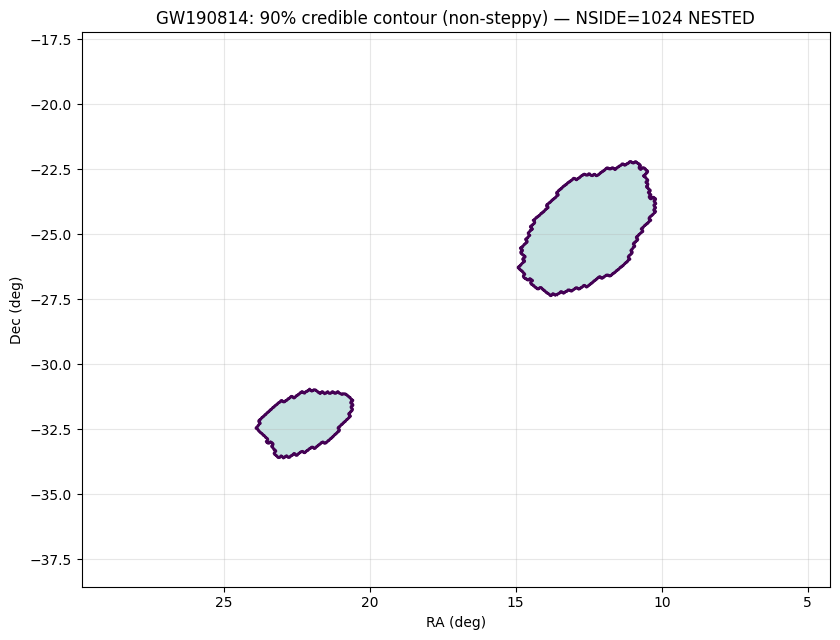

In [13]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Zoomed plot grid resolution (higher = smoother contour, slower)
NGRID_RA = 1400
NGRID_DEC = 700

# Padding around the credible region (deg)
PAD_RA = 6.0
PAD_DEC = 5.0

FILL_REGION = True  # True = filled region + contour; False = contour only

# ---------- Imports (NO pip installs here) ----------
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix


# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

print("Skymap exists:", os.path.exists(fname))


# ---------- Read FITS header + table ----------
hdr = fits.getheader(fname, 1)          # ext 1 is usually the sky map table
t = Table.read(fname, hdu=1)
print("Columns:", t.colnames)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    print("Warning: unknown ORDERING:", ordering, "-> assuming NESTED")
    ordering = "NESTED"
order_for_healpix = "nested" if ordering == "NESTED" else "ring"

if "PROB" not in t.colnames:
    raise KeyError("Expected a raster sky map with a PROB column (probability per pixel).")

nside = hdr.get("NSIDE", None)
if nside is None:
    # Infer NSIDE from number of pixels if header is missing it
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
tot = p.sum()
if not np.isfinite(tot) or tot <= 0:
    raise RuntimeError("PROB column sums to non-finite or zero.")
p = p / tot  # normalize defensively

hp = HEALPix(nside=nside, order=order_for_healpix, frame="icrs")

print(f"Detected raster sky map: NSIDE={nside}, ORDERING={ordering}")
print("Total prob:", p.sum())


# ---------- Credible-level field (non-steppy contours) ----------
# For each pixel, credible_level[pix] = cumulative probability enclosed
# by all pixels with probability >= that pixel.
order = np.argsort(p)[::-1]
cum = np.cumsum(p[order])
credible_level = np.empty_like(p)
credible_level[order] = cum

# We'll still use the <=0.9 region just to compute a good zoom window.
mask90 = credible_level <= CREDIBLE
mask_pix = np.where(mask90)[0]

print(f"Pixels in {int(CREDIBLE*100)}% region:", mask_pix.size, "mass:", p[mask90].sum())


# ---------- Zoom window (wrap-safe RA) ----------
lon_c, lat_c = hp.healpix_to_lonlat(mask_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    """Smallest RA arc covering points (wrap-safe), returned as ra_min, ra_max in 0..360."""
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    ra_min = (start - pad_deg) % 360.0
    ra_max = (end + pad_deg) % 360.0
    return ra_min, ra_max

def ra_linspace_wrap(ra_min, ra_max, n):
    """Linspace over an RA window that may cross 360."""
    ra_min = ra_min % 360.0
    ra_max = ra_max % 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    else:
        a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
        b = np.linspace(0.0, ra_max, n - len(a))
        return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, pad_deg=PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC


# ---------- Build a dense RA/Dec grid over the zoom window ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp.lonlat_to_healpix(RA, DEC)

# IMPORTANT: contour the credible-level scalar field, not the binary mask
Z = credible_level[grid_pix]


# ---------- Plot (zoomed RA/Dec) ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

# Fill the 0..0.9 region and draw the 0.9 contour
if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
                levels=[0.0, CREDIBLE], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
           levels=[CREDIBLE], linewidths=2)

# Astronomy convention: RA increases to the left.
# If window wraps across 360, shift RA>180 down by 360 for a continuous axis.
ra_plot = RA.to_value(u.deg)
wrap = ra_min > ra_max

if wrap:
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)

    # Replot using shifted RA coordinates
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()

    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z,
                    levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z,
               levels=[CREDIBLE], linewidths=2)

    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)  # inverted
else:
    ax.set_xlim(ra_max, ra_min)      # inverted

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% credible contour (non-steppy) — NSIDE={nside} {ordering}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NSIDE=1024 ORDERING=NESTED   sum(p)=1.000000


/tmp/ipykernel_7752/976181294.py:60: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% pixels: 5754  mass=0.899996


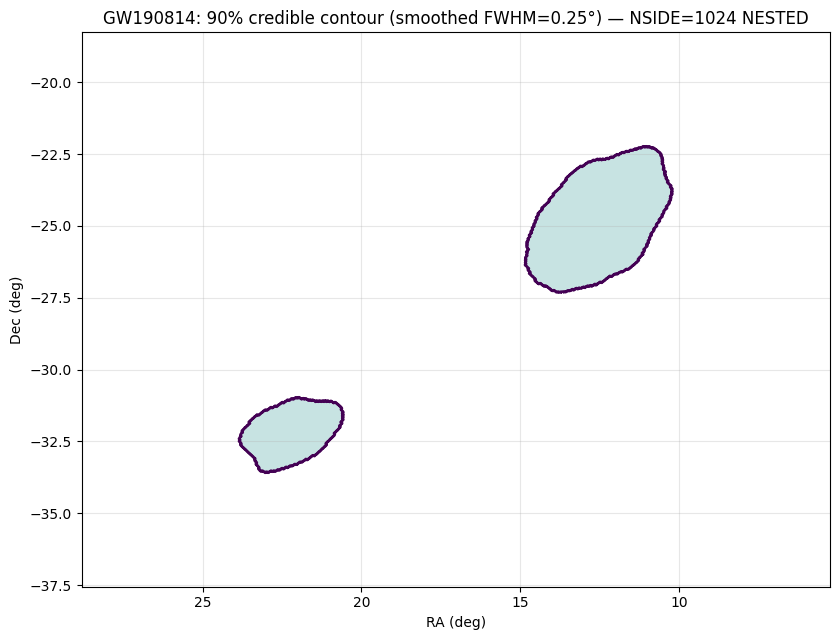

In [14]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Smoothing kernel (degrees). 0 = no smoothing.
SMOOTH_FWHM_DEG = 0.25   # try 0.2–0.4

# Zoom plot grid resolution
NGRID_RA = 1800
NGRID_DEC = 900
PAD_RA = 5.0
PAD_DEC = 4.0
FILL_REGION = True

# ---------- Imports ----------
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix

import healpy as hp  # <-- for spherical smoothing + (optional) reordering

# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read header + table (raster case) ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"NSIDE={nside} ORDERING={ordering}   sum(p)={p.sum():.6f}")

# ---------- Smooth on the sphere (healpy works in RING by default) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    # enforce non-negative + renormalize (smoothing can make tiny negatives numerically)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

# convert back to the map ordering we’ll use for astropy-healpix plotting
if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Build credible-level field from the (smoothed) map ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])

credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% pixels: {mask_pix.size}  mass={p_s[mask90].sum():.6f}")

# ---------- Setup HEALPix object for coordinate transforms ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Zoom window from mask pixels ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(mask_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC

# ---------- Grid + contour of the credible scalar field ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC)
Z = credible[grid_pix]

# ---------- Plot ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
                levels=[0.0, CREDIBLE], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
           levels=[CREDIBLE], linewidths=2)

# RA increases to the left; handle wrap by shifting RA>180 down by 360
ra_plot = RA.to_value(u.deg)
wrap = ra_min > ra_max
if wrap:
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2)
    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: 90% credible contour (smoothed FWHM={SMOOTH_FWHM_DEG}°) — NSIDE={nside} {ordering}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NSIDE=1024 ORDERING=NESTED   sum(p)=1.000000


/tmp/ipykernel_7752/933968634.py:61: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% pixels total: 5754  mass=0.899996
Islands found: 2 masses: [0.82471229 0.07528329]
Main island: pixels=4294, mass=0.824712


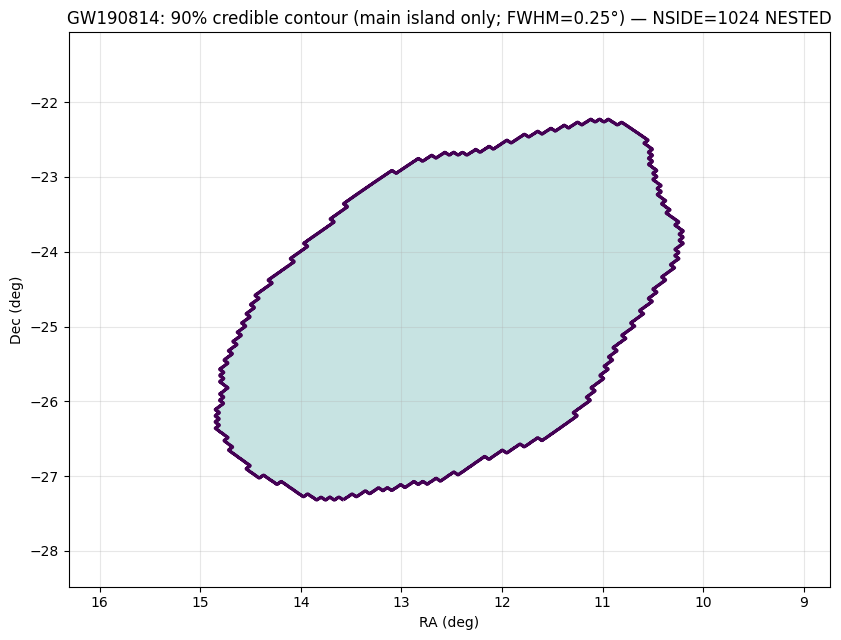

In [20]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Smoothing kernel (degrees). 0 = no smoothing.
SMOOTH_FWHM_DEG = 0.25   # try 0.2–0.4

# Zoom plot grid resolution
NGRID_RA = 3500
NGRID_DEC = 1750
PAD_RA = 1.5
PAD_DEC = 1.2
FILL_REGION = True

# Connectivity for "islands": 8-neighbour HEALPix adjacency (standard)
# (HEALPix neighbours returns up to 8 neighbours; -1 means none)
# ---------- Imports ----------
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix
import healpy as hp  # spherical smoothing + reorder

# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read header + table ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"NSIDE={nside} ORDERING={ordering}   sum(p)={p.sum():.6f}")

# ---------- Smooth on the sphere (healpy smoothing works in RING) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

# Back to original ordering for astropy-healpix
if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Credible-level field from smoothed map ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])
credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% pixels total: {mask_pix.size}  mass={p_s[mask90].sum():.6f}")

# ---------- HEALPix object for neighbours + coordinate transforms ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Find connected components (islands) within the 90% mask ----------
mask_set = set(mask_pix.tolist())
visited = set()

components = []          # list of lists of pixel indices
components_mass = []     # probability mass per component (using p_s)

for start in mask_pix:
    if start in visited:
        continue

    # BFS/DFS
    stack = [int(start)]
    visited.add(int(start))
    comp = []
    mass = 0.0

    while stack:
        pix = stack.pop()
        comp.append(pix)
        mass += float(p_s[pix])

        neigh = hp_ast.neighbours(pix)  # up to 8 neighbours; may include -1
        for nb in neigh:
            nb_int = int(nb)
            if nb_int >= 0 and nb_int in mask_set and nb_int not in visited:
                visited.add(nb_int)
                stack.append(nb_int)

    components.append(comp)
    components_mass.append(mass)

components_mass = np.array(components_mass, dtype=float)
print("Islands found:", len(components), "masses:", components_mass)

main_i = int(np.argmax(components_mass))
main_pix = np.array(components[main_i], dtype=int)
print(f"Main island: pixels={main_pix.size}, mass={components_mass[main_i]:.6f}")

# ---------- Zoom window from MAIN island only ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(main_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC

# ---------- Build grid + contour credible field at 0.9 ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC)
Z = credible[grid_pix]  # scalar credible field (smoothed via p_s)

# ---------- Plot ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# RA increases to the left; handle wrap by shifting RA>180 down by 360
ra_plot = RA.to_value(u.deg)
wrap = ra_min > ra_max
if wrap:
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2)

    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(
    f"GW190814: {int(CREDIBLE*100)}% credible contour (main island only; FWHM={SMOOTH_FWHM_DEG}°) — NSIDE={nside} {ordering}"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NSIDE=1024 ORDERING=NESTED   sum(p)=1.000000


/tmp/ipykernel_7752/1464504262.py:66: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% pixels total: 5754  mass=0.899996
Main island: pixels=4294, mass=0.824712
Galaxies loaded: 273
Inside main-island 90% region: 269 / 273


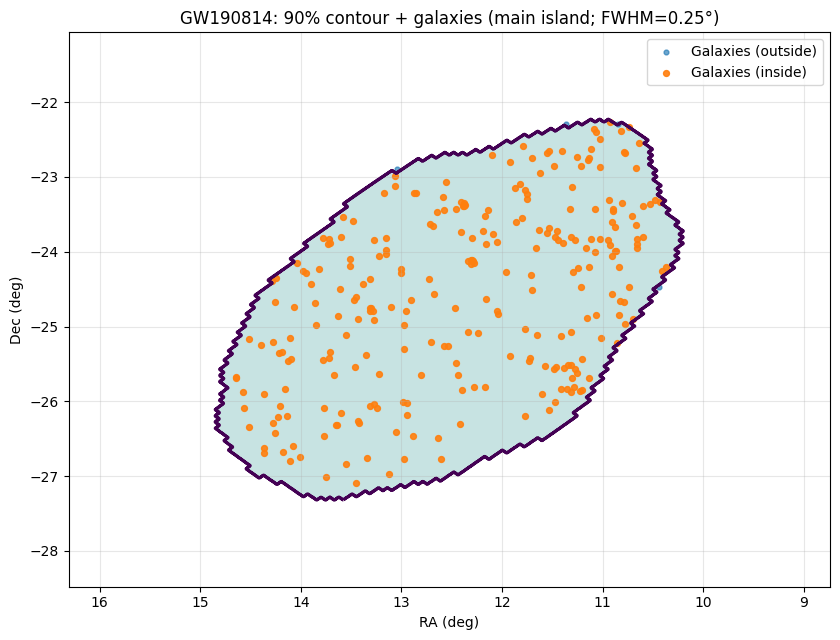

In [22]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

SMOOTH_FWHM_DEG = 0.25   # smoothing for nicer contour
NGRID_RA = 3500
NGRID_DEC = 1750
PAD_RA = 1.5
PAD_DEC = 1.2
FILL_REGION = True

# Your galaxy CSV path:
GALAXY_CSV = "galaxy.csv"   # <-- change me

# Column names in the CSV:
RA_COL = "ra"     # or "RA"
DEC_COL = "dec"   # or "Dec"

# ---------- Imports ----------
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix

import healpy as hp
import pandas as pd

# ---------- Download skymap ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read skymap (raster PROB) ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"NSIDE={nside} ORDERING={ordering}   sum(p)={p.sum():.6f}")

# ---------- Smooth on sphere (healpy uses RING) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Credible-level field ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])
credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% pixels total: {mask_pix.size}  mass={p_s[mask90].sum():.6f}")

# ---------- HEALPix helper ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Find connected components (main island only) ----------
mask_set = set(mask_pix.tolist())
visited = set()
components = []
components_mass = []

for start in mask_pix:
    s = int(start)
    if s in visited:
        continue
    stack = [s]
    visited.add(s)
    comp = []
    mass = 0.0

    while stack:
        pix = stack.pop()
        comp.append(pix)
        mass += float(p_s[pix])

        neigh = hp_ast.neighbours(pix)
        for nb in neigh:
            nb = int(nb)
            if nb >= 0 and nb in mask_set and nb not in visited:
                visited.add(nb)
                stack.append(nb)

    components.append(comp)
    components_mass.append(mass)

components_mass = np.array(components_mass, dtype=float)
main_i = int(np.argmax(components_mass))
main_pix = np.array(components[main_i], dtype=int)
print(f"Main island: pixels={main_pix.size}, mass={components_mass[main_i]:.6f}")

# We'll use this mask for "inside/outside" galaxy coloring:
mask_main = np.zeros_like(mask90, dtype=bool)
mask_main[main_pix] = True

# ---------- Zoom window from main island ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(main_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC

# ---------- Build contour grid ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC)
Z = credible[grid_pix]

# ---------- Load galaxies ----------
df = pd.read_csv(GALAXY_CSV)

# tolerant column lookup
cols_lower = {c.lower(): c for c in df.columns}
ra_key = cols_lower.get(RA_COL.lower(), RA_COL)
dec_key = cols_lower.get(DEC_COL.lower(), DEC_COL)

if ra_key not in df.columns or dec_key not in df.columns:
    raise KeyError(f"Couldn't find RA/Dec columns. Have {list(df.columns)}; tried {RA_COL}, {DEC_COL}.")

gal_ra = df[ra_key].astype(float).to_numpy()
gal_dec = df[dec_key].astype(float).to_numpy()

# Wrap RA into 0..360 for HEALPix
gal_ra_wrapped = np.mod(gal_ra, 360.0) * u.deg
gal_dec_u = gal_dec * u.deg

gal_pix = hp_ast.lonlat_to_healpix(gal_ra_wrapped, gal_dec_u)
gal_in = mask_main[gal_pix]

print(f"Galaxies loaded: {len(gal_ra)}")
print(f"Inside main-island {int(CREDIBLE*100)}% region: {gal_in.sum()} / {len(gal_in)}")

# ---------- Plot ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

# Contour fill + line
if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# Plot galaxies: inside vs outside
# (No fixed colors requested; matplotlib will choose defaults)
ax.scatter(gal_ra[~gal_in], gal_dec[~gal_in], s=12, alpha=0.65, marker="o", label="Galaxies (outside)")
ax.scatter(gal_ra[gal_in],  gal_dec[gal_in],  s=18, alpha=0.9,  marker="o", label="Galaxies (inside)")

# RA axis handling (invert; wrap-safe)
wrap = ra_min > ra_max
if wrap:
    # shift display RA for continuity
    def shift_ra(x):
        x = np.mod(x, 360.0)
        return np.where(x > 180.0, x - 360.0, x)

    ra_plot = shift_ra(RA.to_value(u.deg))
    gal_ra_plot = shift_ra(gal_ra)

    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

    ax.scatter(gal_ra_plot[~gal_in], gal_dec[~gal_in], s=12, alpha=0.65, marker="o", label="Galaxies (outside)")
    ax.scatter(gal_ra_plot[gal_in],  gal_dec[gal_in],  s=18, alpha=0.9,  marker="o", label="Galaxies (inside)")

    ra_min_s = (ra_min - 360.0) if ra_min > 180.0 else ra_min
    ra_max_s = (ra_max - 360.0) if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% contour + galaxies (main island; FWHM={SMOOTH_FWHM_DEG}°)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [23]:
import numpy as np

# ----------------------------
# Config for WEAVE MOS
# ----------------------------
RADIUS_DEG = 1.0     # WEAVE MOS radius
NMAX = 10            # compute solutions for N=1..NMAX
USE_ONLY_GALAXIES_IN_ISLAND_AS_CANDIDATES = True  # recommended for speed + constraint

# ----------------------------
# Helpers: spherical geometry
# ----------------------------
def radec_to_unitvec(ra_deg, dec_deg):
    """Convert RA/Dec (deg) to Cartesian unit vectors."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    cosd = np.cos(dec)
    return np.column_stack([cosd*np.cos(ra), cosd*np.sin(ra), np.sin(dec)])

def angular_sep_deg_vec(v1, v2):
    """Angular separation (deg) between vectors v1 (N,3) and v2 (M,3) via dot products."""
    # returns (N,M)
    dots = np.clip(v1 @ v2.T, -1.0, 1.0)
    return np.rad2deg(np.arccos(dots))

def is_center_in_main_island(ra_deg, dec_deg, hp_ast, mask_main):
    """Check if a candidate center falls in the main island mask."""
    import astropy.units as u
    ra_u = (np.mod(ra_deg, 360.0) * u.deg)
    dec_u = (dec_deg * u.deg)
    pix = hp_ast.lonlat_to_healpix(ra_u, dec_u)
    return bool(mask_main[int(pix)])

# ----------------------------
# Build galaxy point set to cover
# ----------------------------
# gal_ra, gal_dec are your full catalog arrays (deg)
gal_ra = np.asarray(gal_ra, dtype=float)
gal_dec = np.asarray(gal_dec, dtype=float)

# Determine which galaxies are in the main island (you already computed gal_pix + mask_main earlier)
# If you don't have gal_pix/gal_in already, recompute here:
import astropy.units as u
gal_pix = hp_ast.lonlat_to_healpix((np.mod(gal_ra, 360.0) * u.deg), (gal_dec * u.deg))
gal_in_main = mask_main[np.asarray(gal_pix, dtype=int)]

# For the proposal exercise you probably want to cover only galaxies in/near the localisation.
# If you want "all galaxies plotted" (including outside), set TARGET = all.
TARGET = np.where(gal_in_main)[0]  # indices of galaxies to cover
# TARGET = np.arange(len(gal_ra))  # uncomment if you instead want to cover the entire input catalog

target_ra = gal_ra[TARGET]
target_dec = gal_dec[TARGET]
target_vec = radec_to_unitvec(target_ra, target_dec)

print(f"Target galaxies for coverage: {len(TARGET)}")

# ----------------------------
# Candidate pointing centers
# ----------------------------
# A very practical choice is: candidate centers = the galaxy positions (in main island),
# because the optimum for max-count under a fixed radius almost always occurs with a boundary
# "supported" by points. With 300 galaxies this is plenty.

if USE_ONLY_GALAXIES_IN_ISLAND_AS_CANDIDATES:
    cand_idx = np.arange(len(TARGET))  # candidate centers = target galaxies
    cand_ra = target_ra.copy()
    cand_dec = target_dec.copy()
else:
    # Candidate centers = all galaxies (or you can add a grid later)
    cand_ra = gal_ra.copy()
    cand_dec = gal_dec.copy()

# Enforce "center must be in the island" explicitly
in_island = np.array([is_center_in_main_island(r, d, hp_ast, mask_main) for r, d in zip(cand_ra, cand_dec)])
cand_ra = cand_ra[in_island]
cand_dec = cand_dec[in_island]

if len(cand_ra) == 0:
    raise RuntimeError("No candidate centers remained after island constraint.")

cand_vec = radec_to_unitvec(cand_ra, cand_dec)

# Precompute which targets are within 1° of each candidate center
# cover_matrix[i] = boolean mask over targets covered by candidate i
sep = angular_sep_deg_vec(cand_vec, target_vec)           # (Ncand, Ntarget)
cover_matrix = (sep <= RADIUS_DEG)

# ----------------------------
# Greedy maximum coverage for N pointings
# ----------------------------
covered = np.zeros(len(TARGET), dtype=bool)
pointings = []

for n in range(1, NMAX + 1):
    # marginal gain for each candidate = number of uncovered galaxies it would newly cover
    gains = np.sum(cover_matrix & (~covered[None, :]), axis=1)
    best = int(np.argmax(gains))
    best_gain = int(gains[best])

    if best_gain == 0:
        print(f"Stopping early at N={n-1}: no further galaxies can be added with radius={RADIUS_DEG}°.")
        break

    # update covered set
    newly = cover_matrix[best] & (~covered)
    covered |= cover_matrix[best]

    # record
    cum = int(covered.sum())
    pct = 100.0 * cum / len(TARGET)

    pointings.append({
        "N": n,
        "ra_deg": float(cand_ra[best]),
        "dec_deg": float(cand_dec[best]),
        "newly_covered": int(newly.sum()),
        "cumulative_covered": cum,
        "cumulative_pct": pct
    })

# ----------------------------
# Report
# ----------------------------
if pointings:
    print("\nBest single pointing (N=1):")
    p1 = pointings[0]
    print(f"  center RA,Dec = ({p1['ra_deg']:.6f}°, {p1['dec_deg']:.6f}°)")
    print(f"  galaxies covered = {p1['cumulative_covered']} / {len(TARGET)}  ({p1['cumulative_pct']:.2f}%)")

print("\nGreedy coverage curve:")
for p in pointings:
    print(f"  N={p['N']:2d}  center=({p['ra_deg']:.4f}, {p['dec_deg']:.4f})  "
          f"+{p['newly_covered']:3d}  cum={p['cumulative_covered']:3d}  ({p['cumulative_pct']:.2f}%)")

Target galaxies for coverage: 269
Stopping early at N=9: no further galaxies can be added with radius=1.0°.

Best single pointing (N=1):
  center RA,Dec = (11.536177°, -23.678470°)
  galaxies covered = 81 / 269  (30.11%)

Greedy coverage curve:
  N= 1  center=(11.5362, -23.6785)  + 81  cum= 81  (30.11%)
  N= 2  center=(13.3102, -24.7975)  + 61  cum=142  (52.79%)
  N= 3  center=(11.6543, -25.1149)  + 45  cum=187  (69.52%)
  N= 4  center=(13.6385, -26.3185)  + 38  cum=225  (83.64%)
  N= 5  center=(11.2995, -23.1319)  + 18  cum=243  (90.33%)
  N= 6  center=(13.1577, -23.8209)  + 15  cum=258  (95.91%)
  N= 7  center=(11.7764, -26.2017)  +  4  cum=262  (97.40%)
  N= 8  center=(14.2047, -26.0660)  +  4  cum=266  (98.88%)
  N= 9  center=(10.4143, -24.2531)  +  3  cum=269  (100.00%)


In [24]:
from matplotlib.patches import Circle

# Plot circles for each pointing
for p in pointings:
    ra = p["ra_deg"]
    dec = p["dec_deg"]

    circle = Circle(
        (ra, dec),
        RADIUS_DEG,
        fill=False,
        linewidth=2,
        linestyle="--",
        alpha=0.9
    )

    ax.add_patch(circle)

    # label the pointing
    ax.text(
        ra,
        dec,
        f"P{p['N']}",
        ha="center",
        va="center",
        fontsize=10,
        weight="bold"
    )